# EDA e Baseline — Propensão de Compra (Online Shoppers)

**Autor:** Alessandro Stefani
**Data:** 2026-08-29
**Disciplina:** Tech Challenge — Fase 02 (Containers e Ambientes Reprodutíveis)
**Etapa:** 1 — Entendimento dos dados e modelo base
**Descrição:** Análise exploratória enxuta do dataset *Online Shoppers Purchasing Intention* e
construção de um baseline de classificação, para definir o pré-processamento que vai ser
implementado no pacote `propensao`.

**Dataset:** `data/raw/online_shoppers_intention.csv` (UCI) — cada linha é uma **sessão de
navegação**; o alvo `Revenue` indica se a sessão terminou em compra.

> **Escopo:** este notebook é ferramenta de decisão, não entregável. O foco do TC é engenharia
> (Docker, DVC, MLflow, Poetry = 90% da nota); modelagem vale 10%. Sem tuning, sem validação
> cruzada — só o suficiente para escolher o pré-processamento e ter uma referência de desempenho.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
CAMINHO_DADOS = Path("..") / "data" / "raw" / "online_shoppers_intention.csv"

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## 1. Carga e visão geral

In [2]:
df = pd.read_csv(CAMINHO_DADOS)
print(f"{df.shape[0]:,} sessões x {df.shape[1]} colunas")
df.head()

12,330 sessões x 18 colunas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
resumo = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "nunique": df.nunique(),
    }
)
print(f"Duplicatas exatas: {df.duplicated().sum()}")
resumo

Duplicatas exatas: 125


,dtype,nulos,nunique
Administrative,int64,0,27
Administrative_Duration,float64,0,3335
Informational,int64,0,17
Informational_Duration,float64,0,1258
ProductRelated,int64,0,311
ProductRelated_Duration,float64,0,9551
BounceRates,float64,0,1872
ExitRates,float64,0,4777
PageValues,float64,0,2704
SpecialDay,float64,0,6


**Leitura:**

- **Zero valores nulos** — não vai ser preciso imputação, o que simplifica bastante o pipeline.
- **125 duplicatas exatas** (~1%). Duas sessões idênticas são plausíveis na vida real, mas
  duplicatas exatas vazam entre treino e teste no split. **Decisão: remover** no estágio `prepare`.
- `Weekend` e `Revenue` são `bool`; `Month` e `VisitorType` são texto; o resto é numérico —
  mas **nem todo inteiro é número de verdade** (ver §4).

## 2. O alvo

In [4]:
dist = df["Revenue"].value_counts(normalize=True)
print(dist.rename("proporção").to_frame().to_string(float_format="{:.4f}".format))
print(f"\nPrevalência da classe positiva: {dist[True]:.2%}")

         proporção
Revenue           
False       0.8453
True        0.1547

Prevalência da classe positiva: 15.47%


**Desbalanceado, mas não extremo:** 15,5% das sessões convertem. Duas consequências
para o resto do projeto:

1. **Acurácia é inútil aqui** — chutar "ninguém compra" acerta 84,5%. A métrica principal vai ser
   **PR-AUC** (`average_precision`), que olha só o desempenho na classe positiva.
2. Modelos lineares precisam de `class_weight="balanced"` para não ignorarem a classe rara.

## 3. Variáveis numéricas — assimetria

In [5]:
ID_DISFARCADOS = ["OperatingSystems", "Browser", "Region", "TrafficType"]
NUMERICAS = df.select_dtypes("number").columns.drop(ID_DISFARCADOS)

(
    df[NUMERICAS]
    .describe()
    .T[["mean", "std", "min", "50%", "max"]]
    .assign(assimetria=df[NUMERICAS].skew())
    .round(2)
)

,mean,std,min,50%,max,assimetria
Administrative,2.32,3.32,0.0,1.00,27.00,1.96
Administrative_Duration,80.82,176.78,0.0,7.50,3398.75,5.62
Informational,0.50,1.27,0.0,0.00,24.00,4.04
Informational_Duration,34.47,140.75,0.0,0.00,2549.38,7.58
ProductRelated,31.73,44.48,0.0,18.00,705.00,4.34
ProductRelated_Duration,1194.75,1913.67,0.0,598.94,63973.52,7.26
BounceRates,0.02,0.05,0.0,0.00,0.20,2.95
ExitRates,0.04,0.05,0.0,0.03,0.20,2.15
PageValues,5.89,18.57,0.0,0.00,361.76,6.38
SpecialDay,0.06,0.20,0.0,0.00,1.00,3.30


**Assimetria brutal nas contagens e durações.** `ProductRelated_Duration` tem mediana de
599 segundos e máximo de 63.974 — uma sessão de quase 18 horas. São caudas longas típicas de
comportamento de navegação, não erro de medição.

**Decisão:** `log1p` antes de padronizar nessas colunas. `log1p` (e não `log`) porque há muitos
zeros legítimos — sessão que não visitou nenhuma página administrativa, por exemplo.

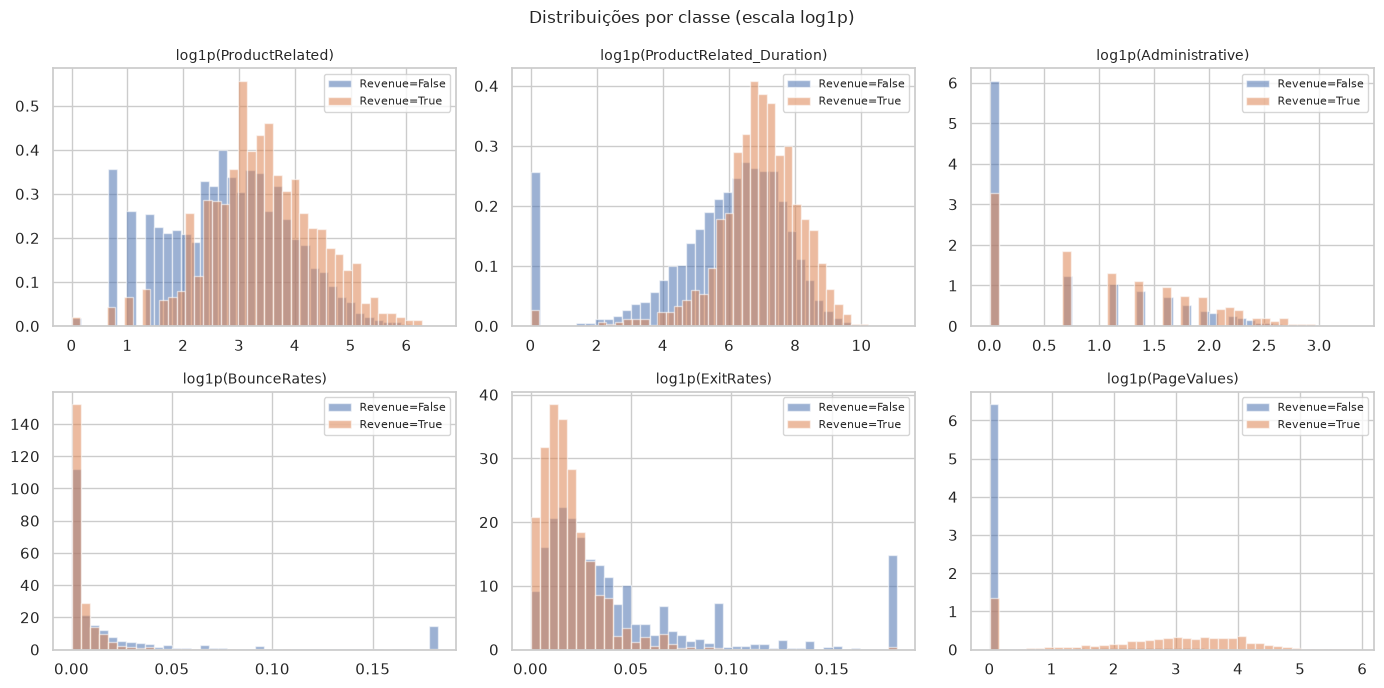

In [6]:
COLS_PLOT = [
    "ProductRelated",
    "ProductRelated_Duration",
    "Administrative",
    "BounceRates",
    "ExitRates",
    "PageValues",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), COLS_PLOT):
    for valor, grupo in df.groupby("Revenue"):
        ax.hist(np.log1p(grupo[col]), bins=40, alpha=0.55, density=True, label=f"Revenue={valor}")
    ax.set_title(f"log1p({col})", fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Distribuições por classe (escala log1p)", fontsize=12)
fig.tight_layout()
plt.show()

`ExitRates` e `BounceRates` separam bem as classes (quem compra abandona menos páginas),
e `PageValues` separa **muito** bem — o que é justamente o problema discutido na §5.

## 4. Variáveis categóricas

In [7]:
CATEGORICAS = ["Month", "VisitorType", "Weekend", *ID_DISFARCADOS]

for col in CATEGORICAS:
    tab = (
        df.groupby(col, observed=True)
        .agg(sessoes=("Revenue", "size"), conversao=("Revenue", "mean"))
        .sort_values("conversao", ascending=False)
    )
    print(f"\n=== {col} ({df[col].nunique()} níveis) ===")
    print(tab.head(6).to_string(float_format="{:.3f}".format))


=== Month (10 níveis) ===
       sessoes  conversao
Month                    
Nov       2998      0.254
Oct        549      0.209
Sep        448      0.192
Aug        433      0.176
Jul        432      0.153
Dec       1727      0.125

=== VisitorType (3 níveis) ===
                   sessoes  conversao
VisitorType                          
New_Visitor           1694      0.249
Other                   85      0.188
Returning_Visitor    10551      0.139

=== Weekend (2 níveis) ===
         sessoes  conversao
Weekend                    
True        2868      0.174
False       9462      0.149

=== OperatingSystems (8 níveis) ===
                  sessoes  conversao
OperatingSystems                    
8                      79      0.215
4                     478      0.178
2                    6601      0.175
5                       6      0.167
1                    2585      0.147
7                       7      0.143

=== Browser (13 níveis) ===
         sessoes  conversao
Browser      

**O ponto mais importante desta seção:** `OperatingSystems`, `Browser`, `Region` e
`TrafficType` são **inteiros que não são ordens**. Passar direto para um modelo linear ensina que
"Browser 13 > Browser 2", o que não significa nada. **Decisão: OneHotEncoder** neles, junto com
`Month`, `VisitorType` e `Weekend`.

Outros dois detalhes:

- `Month` tem **10 níveis** — faltam Jan e Abr — e escreve `'June'` (não `'Jun'`). A dispersão é
  enorme em torno da média de 15,5%: Nov converte 25,4% (Black Friday) e Fev apenas 1,6% — mas Fev
  tem só 184 sessões, então esse extremo é pouco confiável. Mai e Mar, com muito volume, ficam em
  ~10%.
- `VisitorType`: `New_Visitor` converte 24,9% contra 13,9% do `Returning_Visitor` — **1,8x mais**.
  Contraintuitivo à primeira vista, mas coerente: quem já é cliente entra no site por muitos
  motivos além de comprar.

## 5. ⚠️ `PageValues` — o sinal bom demais

`PageValues` é a métrica do Google Analytics que mede o valor médio das páginas visitadas
**antes de uma transação**. Ou seja: carrega informação parcialmente **posterior** ao evento que
queremos prever.

In [8]:
print(f"Sessões com PageValues == 0: {(df['PageValues'] == 0).mean():.1%}")
print(f"Correlação com o alvo:            {df['PageValues'].corr(df['Revenue'].astype(int)):.3f}")

correlacoes = df[NUMERICAS].corrwith(df["Revenue"].astype(int)).abs().sort_values(ascending=False)
print("\nCorrelação absoluta com o alvo (top 5):")
print(correlacoes.head(5).to_string(float_format="{:.3f}".format))

print("\nConversão por presença de PageValues:")
print(
    df.assign(tem_page_value=df["PageValues"] > 0)
    .groupby("tem_page_value")
    .agg(sessoes=("Revenue", "size"), conversao=("Revenue", "mean"))
    .to_string(float_format="{:.3f}".format)
)

Sessões com PageValues == 0: 77.9%
Correlação com o alvo:            0.493

Correlação absoluta com o alvo (top 5):
PageValues                0.493
ExitRates                 0.207
ProductRelated            0.159
ProductRelated_Duration   0.152
BounceRates               0.151

Conversão por presença de PageValues:
                sessoes  conversao
tem_page_value                    
False              9600      0.039
True               2730      0.563


`PageValues` correlaciona **2,4x** mais com o alvo que a segunda colocada (`ExitRates`) e é
**zero em 77,9% das sessões**. Quando é maior que zero, a conversão salta de **3,9% para 56,3%** —
um fator de 14x.

É o mesmo tipo de armadilha do `SatisfactionScore` no TC da Fase 01 (que sozinho levava o PR-AUC de
0,76 para 0,98). Não é vazamento tão descarado — a métrica *é* medida durante a sessão — mas um
modelo que depende dela está, em boa parte, descrevendo o presente em vez de prever o futuro.

**Por isso o §6 treina o mesmo modelo com e sem ela.**

## 6. Baseline

Três candidatos, hold-out estratificado de 20%, sem tuning. Pré-processamento igual ao que vai
para o pacote: `log1p` + padronização nas assimétricas, padronização nas demais numéricas,
one-hot nas categóricas.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

ASSIMETRICAS = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "PageValues",
]
NUMERICAS_SIMPLES = ["BounceRates", "ExitRates", "SpecialDay"]


def construir_preprocessador(usar_page_values: bool = True) -> ColumnTransformer:
    """Monta o ColumnTransformer, opcionalmente descartando PageValues."""
    assimetricas = ASSIMETRICAS if usar_page_values else ASSIMETRICAS[:-1]
    log_e_escala = Pipeline(
        [
            ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("escala", StandardScaler()),
        ]
    )
    return ColumnTransformer(
        [
            ("assimetricas", log_e_escala, assimetricas),
            ("numericas", StandardScaler(), NUMERICAS_SIMPLES),
            # sparse_output=False porque o HistGradientBoosting exige matriz densa
            ("categoricas", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAS),
        ]
    )

In [10]:
dados = df.drop_duplicates()
print(f"{len(df) - len(dados)} duplicatas removidas -> {len(dados):,} sessões")

X = dados.drop(columns="Revenue")
y = dados["Revenue"].astype(int)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"treino: {len(X_treino):,}  |  teste: {len(X_teste):,}")

125 duplicatas removidas -> 12,205 sessões


treino: 9,764  |  teste: 2,441


In [11]:
def avaliar(nome: str, modelo, usar_page_values: bool = True) -> dict:
    """Treina um pipeline no treino e devolve as métricas no hold-out."""
    pipe = Pipeline(
        [("preprocessador", construir_preprocessador(usar_page_values)), ("modelo", modelo)]
    )
    pipe.fit(X_treino, y_treino)
    proba = pipe.predict_proba(X_teste)[:, 1]
    predicao = (proba >= 0.5).astype(int)
    return {
        "modelo": nome,
        "pr_auc": average_precision_score(y_teste, proba),
        "roc_auc": roc_auc_score(y_teste, proba),
        "precisao": precision_score(y_teste, predicao, zero_division=0),
        "recall": recall_score(y_teste, predicao, zero_division=0),
        "f1": f1_score(y_teste, predicao, zero_division=0),
    }


resultados = [
    avaliar("Dummy (prevalência)", DummyClassifier(strategy="prior")),
    avaliar(
        "Regressão Logística",
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    ),
    avaliar("HistGradientBoosting", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
]

pd.DataFrame(resultados).set_index("modelo").round(4)

,pr_auc,roc_auc,precisao,recall,f1
modelo,,,,,
Dummy (prevalência),0.1565,0.5000,0.0000,0.0000,0.0000
Regressão Logística,0.6782,0.9255,0.5601,0.8168,0.6645
HistGradientBoosting,0.7410,0.9304,0.7014,0.6335,0.6657


### 6.1 O mesmo modelo, sem `PageValues`

In [12]:
comparacao = pd.DataFrame(
    [
        avaliar("HistGB — com PageValues", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
        avaliar(
            "HistGB — sem PageValues",
            HistGradientBoostingClassifier(random_state=RANDOM_STATE),
            usar_page_values=False,
        ),
    ]
).set_index("modelo")

queda = 1 - comparacao["pr_auc"].iloc[1] / comparacao["pr_auc"].iloc[0]
print(f"Queda de PR-AUC ao remover PageValues: {queda:.1%}\n")
comparacao.round(4)

Queda de PR-AUC ao remover PageValues: 50.1%



,pr_auc,roc_auc,precisao,recall,f1
modelo,,,,,
HistGB — com PageValues,0.7410,0.9304,0.7014,0.6335,0.6657
HistGB — sem PageValues,0.3699,0.7859,0.4639,0.1178,0.1879


## 7. Conclusões — o que vai para o código

**Pré-processamento** (vira o `ColumnTransformer` em `propensao/preprocess.py`):

| Grupo | Colunas | Transformação |
|---|---|---|
| Assimétricas | contagens de página, durações, `PageValues` | `log1p` + `StandardScaler` |
| Numéricas | `BounceRates`, `ExitRates`, `SpecialDay` | `StandardScaler` |
| Categóricas | `Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region`, `TrafficType` | `OneHotEncoder(handle_unknown="ignore")` |

**Preparação dos dados** (vira `propensao/prepare.py`):

- Remover as 125 duplicatas exatas **antes** do split
- Split estratificado 80/20 com `random_state` fixo vindo do `params.yaml`
- Sem imputação — não há nulos

**Modelagem** (vira `propensao/model.py` + `params.yaml`):

- Métrica principal: **PR-AUC**; acurácia não entra no relatório
- `HistGradientBoostingClassifier` como candidato principal (**PR-AUC 0,741**), Regressão Logística
  como referência interpretável (**0,678**), `DummyClassifier` como piso (**0,157** = a prevalência)
- Sem tuning e sem validação cruzada — fora de escopo nesta fase

### `PageValues`: **decisão — fica fora do modelo** (29/08)

Remover `PageValues` derruba o PR-AUC em **50,1%** (0,741 -> 0,370). Metade do poder preditivo do
modelo vinha de uma única coluna.

Ainda assim, **ela sai**. A documentação do dataset define a variável como *"o valor médio de uma
página que o usuário visitou **antes de completar uma transação**"* — ou seja, ela é **construída a
partir do desfecho que queremos prever**. É *near-target leakage*: não é o alvo entrando no treino
por erro de split, é uma feature cuja própria definição depende da conversão ter acontecido.

O custo foi assumido conscientemente: modelagem vale 10% da nota deste Tech Challenge, e um modelo
mais fraco é preferível a um número inflado por vazamento. O modelo resultante explica
**comportamento de navegação** — páginas visitadas, tempo, taxas de saída, origem de tráfego,
sazonalidade — e não ecoa o funil de checkout já em curso.

A decisão vive em `params.yaml` (`train.usar_page_values: false`) e é reversível numa linha, o que
permite reproduzir os dois cenários com `dvc repro`.